In [1]:
import glob
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = "/Users/pmccarthy/Documents/experimental_data/allen_visual_neuropixels"

In [3]:
pkl_files = glob.glob(f"{data_path}/*psth_responses.pkl")

In [4]:
data = []
for pkl_file in pkl_files:
    data.append(np.load(pkl_file, allow_pickle=True))

In [5]:
total_units = 0
for session_idx in range(len(data)):
    try:
        print(f"Session {session_idx}: {data[session_idx]['responses'].shape[3]} units")
        total_units += data[session_idx]["responses"].shape[3]
    except:
        pass

Session 0: 9 units
Session 1: 8 units
Session 2: 19 units
Session 3: 10 units
Session 4: 13 units
Session 5: 7 units
Session 6: 22 units
Session 7: 7 units
Session 8: 14 units
Session 9: 14 units
Session 10: 17 units
Session 12: 11 units
Session 13: 12 units
Session 14: 8 units
Session 15: 10 units
Session 16: 3 units
Session 17: 15 units
Session 18: 17 units
Session 19: 18 units
Session 20: 6 units
Session 21: 19 units
Session 22: 21 units


In [6]:
data[0]["responses"].shape

(118, 50, 25, 9)

In [7]:
data[0]["responses"].shape

(118, 50, 25, 9)

In [8]:
# Collect valid session responses and concatenate along units axis -> [stim, trial, time, units]
valid = [d["responses"] for d in data if "responses" in d]

# Verify stim/trial/time dims are consistent across sessions
ref_shape = valid[0].shape[:3]
assert all(r.shape[:3] == ref_shape for r in valid), \
    f"Shape mismatch: {[r.shape[:3] for r in valid]}"

responses_all = np.concatenate(valid, axis=3)
print(f"responses_all shape: {responses_all.shape}  (stim, trial, time, units)")

responses_all shape: (118, 50, 25, 280)  (stim, trial, time, units)


/var/folders/8s/q649n2z56_1045fkqy4dygm00000gr/T/ipykernel_80675/1820691095.py:2: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  valid = [d["responses"] for d in data if "responses" in d]


In [9]:
responses_all.shape

(118, 50, 25, 280)

In [10]:
data[0].keys()

dict_keys(['session_id', 'frame_ids', 'unit_ids', 'bin_edges', 'responses', 'trial_start_times', 'unit_info'])

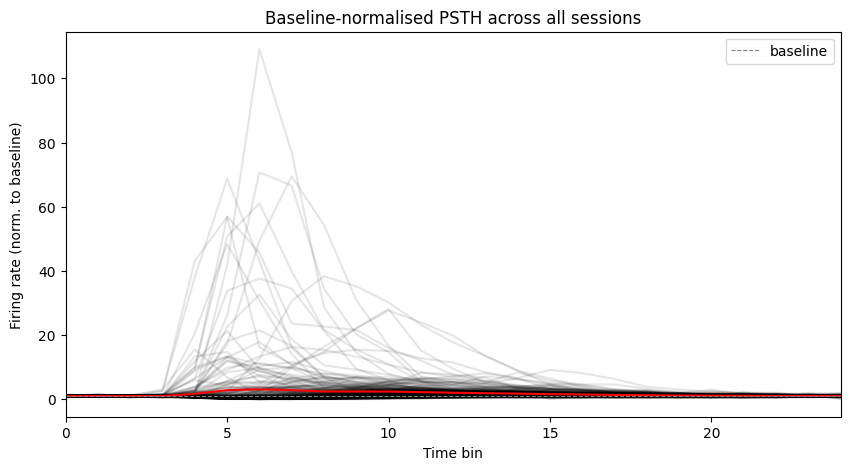

In [11]:
# Normalise each unit's PSTH to its baseline (mean of first 3 time bins)
# responses_all: (stim, trial, time, units)
n_baseline = 3

unit_psth = responses_all.mean(axis=(0, 1))           # (time, units)
baseline = unit_psth[:n_baseline, :].mean(axis=0, keepdims=True)  # (1, units)
baseline = np.where(baseline == 0, 1, baseline)        # avoid div-by-zero for silent units
unit_psth_norm = unit_psth / baseline                  # (time, units)

mean_psth_norm = unit_psth_norm.mean(axis=1)           # (time,)

fig, ax = plt.subplots(figsize=(10, 5))
for unit_idx in range(unit_psth_norm.shape[1]):
    ax.plot(unit_psth_norm[:, unit_idx], alpha=0.1, c="k")
ax.plot(mean_psth_norm, alpha=1, c="r")
ax.axhline(1, ls="--", c="gray", lw=0.8, label="baseline")
ax.set_title("Baseline-normalised PSTH across all sessions")
ax.set_xlabel("Time bin")
ax.set_ylabel("Firing rate (norm. to baseline)")
ax.set_xlim(0, 24)
ax.legend()

Increasing units: 106, Decreasing units: 174


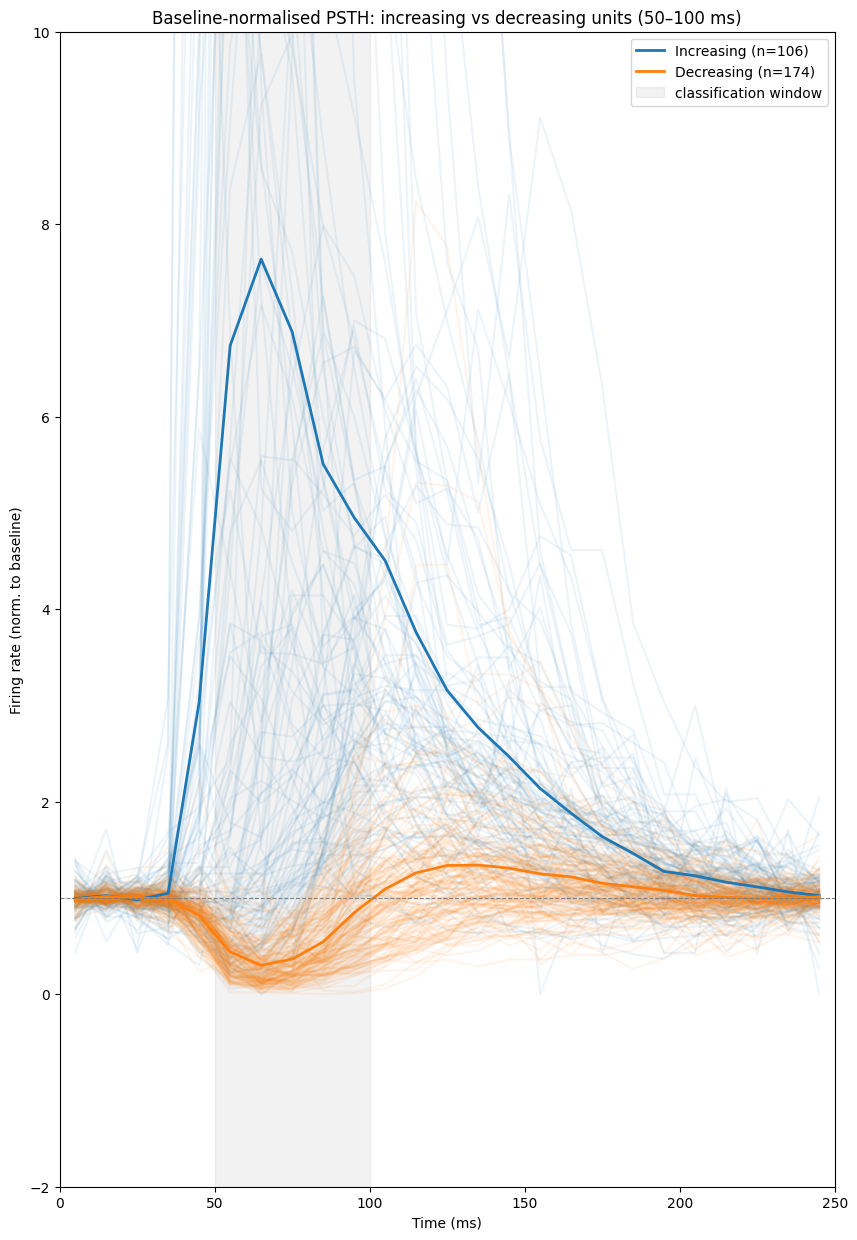

In [15]:
# bin_edges are in seconds, 10 ms per bin -> 50-100 ms = bins 5-9
bin_centers_ms = (data[0]['bin_edges'][:-1] + data[0]['bin_edges'][1:]) / 2 * 1000  # ms
window_mask = (bin_centers_ms >= 50) & (bin_centers_ms < 100)  # bins 5-9

# Mean normalised response in 50-100 ms window per unit
window_mean = unit_psth_norm[window_mask, :].mean(axis=0)  # (units,)

increasing = window_mean > 1
decreasing = window_mean <= 1

print(f"Increasing units: {increasing.sum()}, Decreasing units: {decreasing.sum()}")

fig, ax = plt.subplots(figsize=(10, 15))

t = bin_centers_ms

# Individual unit traces
for unit_idx in np.where(increasing)[0]:
    ax.plot(t, unit_psth_norm[:, unit_idx], alpha=0.08, c="C0")
for unit_idx in np.where(decreasing)[0]:
    ax.plot(t, unit_psth_norm[:, unit_idx], alpha=0.08, c="C1")

# Group means
ax.plot(t, unit_psth_norm[:, increasing].mean(axis=1), c="C0", lw=2,
        label=f"Increasing (n={increasing.sum()})")
ax.plot(t, unit_psth_norm[:, decreasing].mean(axis=1), c="C1", lw=2,
        label=f"Decreasing (n={decreasing.sum()})")

ax.axhline(1, ls="--", c="gray", lw=0.8)
ax.axvspan(50, 100, alpha=0.1, color="gray", label="classification window")
ax.set_title("Baseline-normalised PSTH: increasing vs decreasing units (50–100 ms)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Firing rate (norm. to baseline)")
ax.set_xlim(0, 250)
ax.set_ylim(-2, 10)
ax.legend()